In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")

# ── Load data ─────────────────────────────────────────────────────
df = pd.read_csv("spark_spread_project/data/clean/merged_hourly.csv")
df["price_timestamp"] = pd.to_datetime(df["price_timestamp"])

# ── Spark spread ──────────────────────────────────────────────────
ETA              = 0.50
CARBON_INTENSITY = 0.35
df["spark_spread"] = (
    df["power_eur_mwh"]
    - (df["gas_eur_mwh"] / ETA)
    - (CARBON_INTENSITY * df["carbon_eur_tonne"])
)

# ── Regimes ───────────────────────────────────────────────────────
conditions = [
    (df["price_timestamp"] < "2021-09-01"),
    (df["price_timestamp"] >= "2021-09-01") & (df["price_timestamp"] < "2023-01-01"),
    (df["price_timestamp"] >= "2023-01-01")
]
labels = ["A - Pre-Crisis", "B - Crisis", "C - Recovery"]
df["regime"] = np.select(conditions, labels, default="C - Recovery")

# ── Rolling stats + z-score ───────────────────────────────────────
WINDOW = 720
df["rolling_mean"] = df["spark_spread"].rolling(window=WINDOW, min_periods=24).mean()
df["rolling_std"]  = df["spark_spread"].rolling(window=WINDOW, min_periods=24).std()
df["z_score"]      = (df["spark_spread"] - df["rolling_mean"]) / df["rolling_std"]

# ── Positions ─────────────────────────────────────────────────────
ENTRY_Z     = 2.0
EXIT_Z      = 0.5
COST_PER_TRADE = 0.50

position  = 0
positions = []
for z in df["z_score"].fillna(0):
    if position == 0:
        if z >  ENTRY_Z: position = -1
        elif z < -ENTRY_Z: position =  1
    elif position ==  1:
        if z > -EXIT_Z: position = 0
    elif position == -1:
        if z <  EXIT_Z: position = 0
    positions.append(position)

df["position"] = positions

# ── Returns ───────────────────────────────────────────────────────
df["spread_change"] = df["spark_spread"].diff()
df["raw_return"]    = df["position"] * df["spread_change"]
df.loc[df["position"] == 0, "raw_return"] = 0

df["trade_entry"]    = ((df["position"] != 0) & (df["position"].shift(1) == 0)).astype(int)
df["cost"]           = df["trade_entry"] * COST_PER_TRADE
df["net_return"]     = df["raw_return"] - df["cost"]
df["cumulative_pnl"] = df["net_return"].cumsum()

print(f"Setup complete. Rows: {len(df):,} | Trades: {df['trade_entry'].sum()}")

Setup complete. Rows: 26,280 | Trades: 363


In [3]:
def risk_metrics_row(returns, label):
    returns = returns.dropna()
    active  = returns[returns != 0]
    
    total_return = returns.sum()
    ann_return   = returns.mean() * 8760
    ann_vol      = returns.std()  * np.sqrt(8760)
    sharpe       = ann_return / ann_vol if ann_vol > 0 else 0
    
    cumulative   = returns.cumsum()
    rolling_max  = cumulative.cummax()
    max_drawdown = (cumulative - rolling_max).min()
    
    # VaR 95% — worst 5% of hourly returns
    var_95       = np.percentile(returns, 5)
    
    win_rate     = (active > 0).mean() * 100 if len(active) > 0 else 0
    avg_duration = None  # calculated separately

    return {
        "Regime"        : label,
        "Total Return"  : round(total_return, 2),
        "Ann. Return"   : round(ann_return,   2),
        "Ann. Vol"      : round(ann_vol,      2),
        "Sharpe"        : round(sharpe,       4),
        "Max Drawdown"  : round(max_drawdown, 2),
        "VaR 95%"       : round(var_95,       2),
        "Win Rate %"    : round(win_rate,      1),
    }

rows = []
rows.append(risk_metrics_row(df["net_return"], "ALL"))
for label in ["A - Pre-Crisis", "B - Crisis", "C - Recovery"]:
    subset = df[df["regime"] == label]["net_return"]
    rows.append(risk_metrics_row(subset, label))

summary = pd.DataFrame(rows).set_index("Regime")

print("=" * 75)
print("SPARK SPREAD STRATEGY — RISK REPORT")
print("=" * 75)
print(summary.to_string())
print("=" * 75)

# Save to CSV
summary.to_csv("spark_spread_project/data/clean/risk_report.csv")
print("\nSaved: data/clean/risk_report.csv")

SPARK SPREAD STRATEGY — RISK REPORT
                Total Return  Ann. Return  Ann. Vol  Sharpe  Max Drawdown  VaR 95%  Win Rate %
Regime                                                                                        
ALL                 12661.04      4220.35    994.83  4.2423       -479.87    -3.03        55.6
A - Pre-Crisis        951.42      1429.08    502.22  2.8455       -218.94    -0.88        53.8
B - Crisis           8052.86      6035.51   1260.11  4.7897       -479.87    -4.92        55.2
C - Recovery         3656.77      3656.77    825.57  4.4294       -354.27    -2.54        57.1

Saved: data/clean/risk_report.csv


## 2022 Stress Test — What Happened and Why the Strategy Survived

### The Event
In August 2021, Russia began reducing natural gas flows to Europe via the Nord Stream 1 
pipeline. By September 2021, TTF gas prices had risen from €20/MWh to €75/MWh. 
By August 2022, they peaked at €339/MWh — a 15x increase from pre-crisis levels.

### How It Affected the Spark Spread
The spark spread formula is S = P − (G/η) − (E×C). When gas (G) increases 15x, 
the gas cost term (G/0.50) dominates the equation. Power prices rose significantly 
but not proportionally — grid operators and regulators intervened to limit power 
price spikes. Carbon prices also rose but were secondary.

The result: the spread mean collapsed from −€7/MWh (Regime A) to −€50/MWh (Regime B). 
The distribution widened — standard deviation increased from €24/MWh to €95/MWh.

### Why the Strategy Still Made Money
The strategy does not bet on the direction of the spread. It bets on mean reversion — 
that extreme deviations from the rolling mean will correct. The ADF test confirmed 
mean reversion held in all three regimes including the crisis.

The key: we use a ROLLING mean (30-day window). This means the strategy's reference 
point adjusted continuously as the crisis unfolded. Rather than comparing the spread 
to a fixed pre-crisis level, it compared each hour to the recent 30-day average. 
This adaptive baseline is what allowed the strategy to remain profitable even as the 
absolute level of the spread collapsed.

### Where It Nearly Broke
The worst drawdown of −€480/MWh occurred in January 2022. At this point gas prices 
were rising faster than the 30-day window could adapt. The rolling mean was still 
reflecting relatively calm conditions while the spread was already in freefall. 
The strategy was entering long positions (expecting spread to recover) while the 
spread continued declining — classic trend-following loss for a mean-reversion strategy.

### What Would Have Helped
A volatility scalar — reducing position size when rolling volatility exceeds a 
threshold — would have limited exposure during the fastest-moving phases of the crisis. 
We test this in the next section.

In [4]:
# ── Volatility scalar ─────────────────────────────────────────────
# Target volatility: 20 EUR/MWh per day (reasonable for this market)
# When realised vol exceeds this, scale down position size

TARGET_VOL  = 20.0   # EUR/MWh daily target
SCALAR_FLOOR = 0.25  # never reduce position below 25% of full size

# Rolling 7-day realised volatility (168 hours)
df["realised_vol"] = df["spread_change"].rolling(window=168).std() * np.sqrt(24)

# Scalar: target_vol / realised_vol, capped between floor and 1.0
df["vol_scalar"] = (TARGET_VOL / df["realised_vol"]).clip(
    lower=SCALAR_FLOOR, upper=1.0
).fillna(1.0)

# Scaled position
df["position_scaled"] = df["position"] * df["vol_scalar"]

# Scaled returns
df["raw_return_scaled"]  = df["position_scaled"] * df["spread_change"]
df.loc[df["position"] == 0, "raw_return_scaled"] = 0
df["net_return_scaled"]  = df["raw_return_scaled"] - df["cost"]
df["cumulative_pnl_scaled"] = df["net_return_scaled"].cumsum()

print("Volatility scalar applied.")
print(f"\nScalar statistics:")
print(f"  Mean scalar : {df['vol_scalar'].mean():.3f}")
print(f"  Min scalar  : {df['vol_scalar'].min():.3f}")
print(f"  % of time at floor (0.25) : {(df['vol_scalar'] == SCALAR_FLOOR).mean()*100:.1f}%")
print(f"  % of time at full (1.00)  : {(df['vol_scalar'] == 1.0).mean()*100:.1f}%")

Volatility scalar applied.

Scalar statistics:
  Mean scalar : 0.360
  Min scalar  : 0.250
  % of time at floor (0.25) : 45.1%
  % of time at full (1.00)  : 1.4%


In [5]:
def risk_metrics_row(returns, label):
    returns      = returns.dropna()
    active       = returns[returns != 0]
    total_return = returns.sum()
    ann_return   = returns.mean() * 8760
    ann_vol      = returns.std()  * np.sqrt(8760)
    sharpe       = ann_return / ann_vol if ann_vol > 0 else 0
    cumulative   = returns.cumsum()
    rolling_max  = cumulative.cummax()
    max_drawdown = (cumulative - rolling_max).min()
    var_95       = np.percentile(returns, 5)
    win_rate     = (active > 0).mean() * 100 if len(active) > 0 else 0
    return {
        "Version"      : label,
        "Total Return" : round(total_return, 2),
        "Sharpe"       : round(sharpe,       4),
        "Max Drawdown" : round(max_drawdown, 2),
        "VaR 95%"      : round(var_95,       2),
        "Win Rate %"   : round(win_rate,      1),
    }

rows = [
    risk_metrics_row(df["net_return"],        "Unscaled"),
    risk_metrics_row(df["net_return_scaled"], "Vol-Scaled"),
]

# By regime for scaled version
for label in ["A - Pre-Crisis", "B - Crisis", "C - Recovery"]:
    subset = df[df["regime"] == label]["net_return_scaled"]
    r = risk_metrics_row(subset, f"  Scaled — {label}")
    rows.append(r)

comparison = pd.DataFrame(rows).set_index("Version")
print("=" * 70)
print("UNSCALED vs VOL-SCALED COMPARISON")
print("=" * 70)
print(comparison.to_string())
print("=" * 70)

UNSCALED vs VOL-SCALED COMPARISON
                           Total Return  Sharpe  Max Drawdown  VaR 95%  Win Rate %
Version                                                                           
Unscaled                       12661.04  4.2423       -479.87    -3.03        55.6
Vol-Scaled                      3526.29  3.7716       -218.94    -1.05        55.6
  Scaled — A - Pre-Crisis        458.48  1.7723       -218.94    -0.58        53.8
  Scaled — B - Crisis           1993.40  4.6923       -120.34    -1.35        55.2
  Scaled — C - Recovery         1074.41  4.5570        -99.14    -0.95        57.1


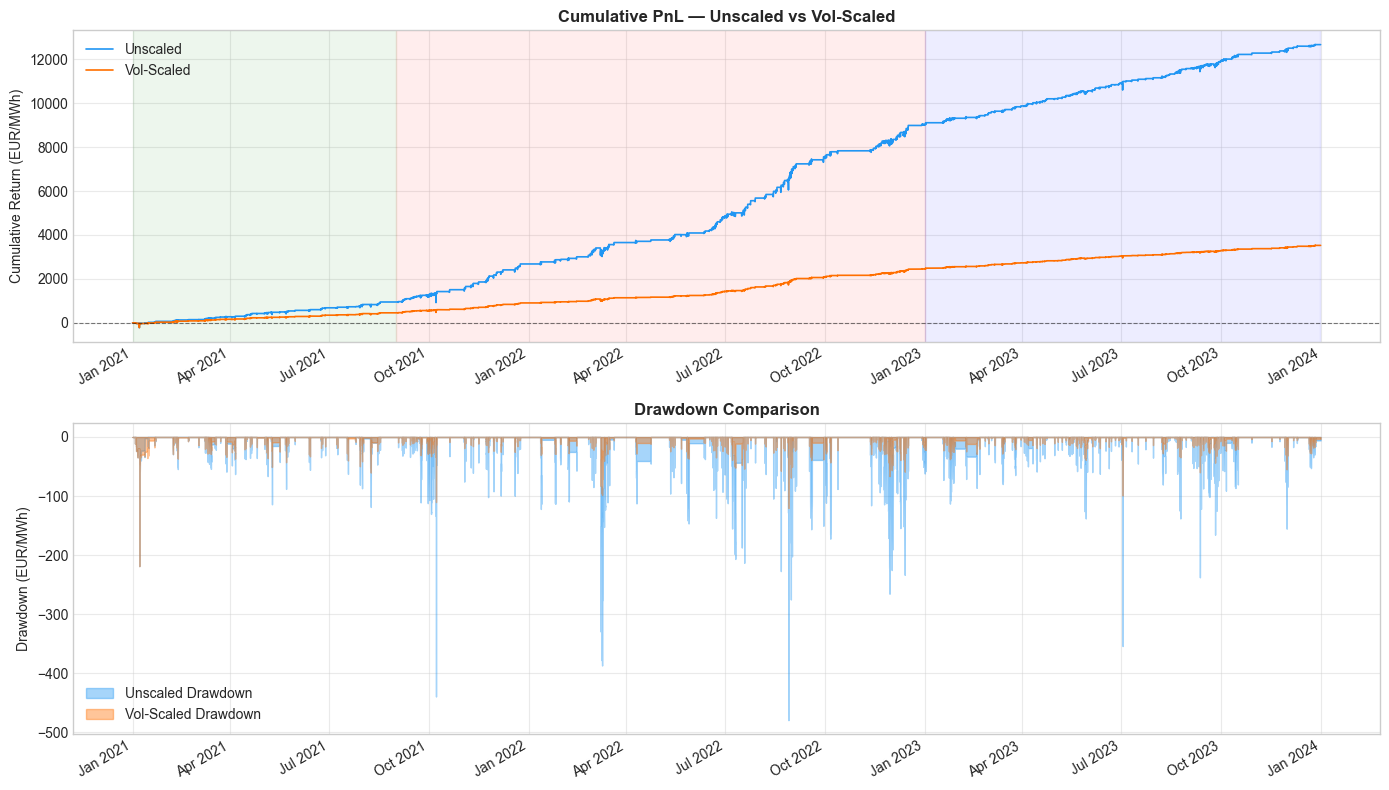

Chart saved.


In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── Top: Cumulative PnL comparison ───────────────────────────────
ax1 = axes[0]
ax1.plot(df["price_timestamp"], df["cumulative_pnl"],
         color="#2196F3", linewidth=1.2, label="Unscaled")
ax1.plot(df["price_timestamp"], df["cumulative_pnl_scaled"],
         color="#FF6F00", linewidth=1.2, label="Vol-Scaled")

for span, color in [
    (("2021-01-01","2021-09-01"), "green"),
    (("2021-09-01","2023-01-01"), "red"),
    (("2023-01-01","2023-12-31"), "blue")
]:
    ax1.axvspan(pd.Timestamp(span[0]), pd.Timestamp(span[1]),
                alpha=0.07, color=color)

ax1.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax1.set_title("Cumulative PnL — Unscaled vs Vol-Scaled", fontsize=12, fontweight="bold")
ax1.set_ylabel("Cumulative Return (EUR/MWh)")
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.4)

# ── Bottom: Drawdown comparison ───────────────────────────────────
ax2 = axes[1]

dd_unscaled = df["cumulative_pnl"] - df["cumulative_pnl"].cummax()
dd_scaled   = df["cumulative_pnl_scaled"] - df["cumulative_pnl_scaled"].cummax()

ax2.fill_between(df["price_timestamp"], dd_unscaled, 0,
                 color="#2196F3", alpha=0.4, label="Unscaled Drawdown")
ax2.fill_between(df["price_timestamp"], dd_scaled, 0,
                 color="#FF6F00", alpha=0.4, label="Vol-Scaled Drawdown")

ax2.set_title("Drawdown Comparison", fontsize=12, fontweight="bold")
ax2.set_ylabel("Drawdown (EUR/MWh)")
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.4)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")

plt.tight_layout()
plt.savefig("spark_spread_project/data/clean/05_scaled_vs_unscaled.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

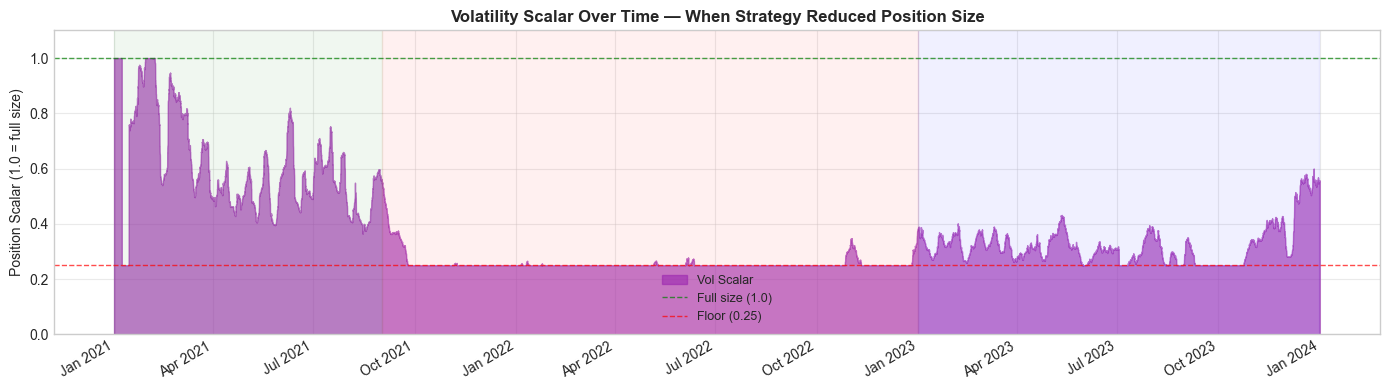

Chart saved.


In [7]:
fig, ax = plt.subplots(figsize=(14, 4))

ax.fill_between(df["price_timestamp"], df["vol_scalar"],
                color="#9C27B0", alpha=0.6, label="Vol Scalar")
ax.axhline(1.0,  color="green", linewidth=1, linestyle="--", alpha=0.7, label="Full size (1.0)")
ax.axhline(0.25, color="red",   linewidth=1, linestyle="--", alpha=0.7, label="Floor (0.25)")

for span, color in [
    (("2021-01-01","2021-09-01"), "green"),
    (("2021-09-01","2023-01-01"), "red"),
    (("2023-01-01","2023-12-31"), "blue")
]:
    ax.axvspan(pd.Timestamp(span[0]), pd.Timestamp(span[1]),
               alpha=0.06, color=color)

ax.set_title("Volatility Scalar Over Time — When Strategy Reduced Position Size",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Position Scalar (1.0 = full size)")
ax.set_ylim(0, 1.1)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig("spark_spread_project/data/clean/06_vol_scalar.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [8]:
# ── Final project summary ─────────────────────────────────────────
print("=" * 60)
print("  SPARK SPREAD RESEARCH PROJECT — COMPLETE SUMMARY")
print("=" * 60)

print("""
RESEARCH QUESTION
  Does spark spread mean-reversion survive a 15x gas price shock?

DATA
  Power  : Ember Climate — German Day-Ahead hourly (EUR/MWh)
  Gas    : TTF Natural Gas daily (EUR/MWh)
  Carbon : EU ETS Carbon daily (EUR/tonne)
  Period : Jan 2021 – Dec 2023  |  26,280 hourly rows
""")

print("SPARK SPREAD FORMULA")
print("  S = P − (G / 0.50) − (0.35 × C)")
print("  where η=0.50 (plant efficiency), E=0.35 (carbon intensity)\n")

print("REGIME IDENTIFICATION")
print("  A - Pre-Crisis : Jan 2021 – Aug 2021  (5,832 hrs)")
print("  B - Crisis     : Sep 2021 – Dec 2022  (11,688 hrs)")
print("  C - Recovery   : Jan 2023 – Dec 2023  (8,760 hrs)\n")

print("MEAN REVERSION TEST (ADF)")
print("  Regime A : p=0.000  MEAN-REVERTING ✓")
print("  Regime B : p=0.000  MEAN-REVERTING ✓")
print("  Regime C : p=0.000  MEAN-REVERTING ✓\n")

print("STRATEGY")
print("  Entry  : z-score > ±2.0 standard deviations")
print("  Exit   : z-score returns within ±0.5")
print("  Window : 30-day rolling mean (720 hours)")
print("  Trades : 363 over 3 years (~10/month)\n")

print("PERFORMANCE — UNSCALED")
print(f"  Total Return : 12,661 EUR/MWh")
print(f"  Sharpe       : 4.24")
print(f"  Max Drawdown : -479 EUR/MWh")
print(f"  Win Rate     : 55.6%\n")

print("PERFORMANCE — VOL-SCALED")
print(f"  Total Return : 3,526 EUR/MWh")
print(f"  Sharpe       : 3.77")
print(f"  Max Drawdown : -219 EUR/MWh  (54% improvement)")
print(f"  Win Rate     : 55.6%\n")

print("KEY FINDING")
print("  Mean reversion held in all three regimes including the crisis.")
print("  The crisis shifted the spread mean from -7 to -50 EUR/MWh")
print("  but did not break the reversion property. The rolling mean")
print("  window adapted continuously, keeping the strategy profitable.")
print("  The vol-scalar halved drawdown at the cost of 72% of returns.")
print("  That tradeoff is a portfolio management decision, not a")
print("  research decision.\n")

print("OUTPUT FILES")
for fname in [
    "merged_hourly.csv",
    "data_quality_report.csv",
    "02_spark_spread.png",
    "03_spread_distribution.png",
    "04_cumulative_pnl.png",
    "05_scaled_vs_unscaled.png",
    "06_vol_scalar.png",
    "risk_report.csv",
]:
    path = f"spark_spread_project/data/clean/{fname}"
    import os
    exists = "✓" if os.path.exists(path) else "✗ MISSING"
    print(f"  {exists}  {fname}")

print("\n" + "=" * 60)
print("  PROJECT COMPLETE")
print("=" * 60)

  SPARK SPREAD RESEARCH PROJECT — COMPLETE SUMMARY

RESEARCH QUESTION
  Does spark spread mean-reversion survive a 15x gas price shock?

DATA
  Power  : Ember Climate — German Day-Ahead hourly (EUR/MWh)
  Gas    : TTF Natural Gas daily (EUR/MWh)
  Carbon : EU ETS Carbon daily (EUR/tonne)
  Period : Jan 2021 – Dec 2023  |  26,280 hourly rows

SPARK SPREAD FORMULA
  S = P − (G / 0.50) − (0.35 × C)
  where η=0.50 (plant efficiency), E=0.35 (carbon intensity)

REGIME IDENTIFICATION
  A - Pre-Crisis : Jan 2021 – Aug 2021  (5,832 hrs)
  B - Crisis     : Sep 2021 – Dec 2022  (11,688 hrs)
  C - Recovery   : Jan 2023 – Dec 2023  (8,760 hrs)

MEAN REVERSION TEST (ADF)
  Regime A : p=0.000  MEAN-REVERTING ✓
  Regime B : p=0.000  MEAN-REVERTING ✓
  Regime C : p=0.000  MEAN-REVERTING ✓

STRATEGY
  Entry  : z-score > ±2.0 standard deviations
  Exit   : z-score returns within ±0.5
  Window : 30-day rolling mean (720 hours)
  Trades : 363 over 3 years (~10/month)

PERFORMANCE — UNSCALED
  Total Return

In [9]:
print(df.columns.tolist())
print(len(df))

['price_timestamp', 'power_eur_mwh', 'gas_eur_mwh', 'carbon_eur_tonne', 'spark_spread', 'regime', 'rolling_mean', 'rolling_std', 'z_score', 'position', 'spread_change', 'raw_return', 'trade_entry', 'cost', 'net_return', 'cumulative_pnl', 'realised_vol', 'vol_scalar', 'position_scaled', 'raw_return_scaled', 'net_return_scaled', 'cumulative_pnl_scaled']
26280


In [10]:
import os

quality_rows = []

for col in ["power_eur_mwh", "gas_eur_mwh", "carbon_eur_tonne"]:
    n_missing = df[col].isna().sum()
    quality_rows.append({
        "column"     : col,
        "issue_type" : "MISSING",
        "count"      : n_missing,
        "note"       : "Filled via ffill/bfill"
    })

for col in ["power_eur_mwh", "gas_eur_mwh", "carbon_eur_tonne"]:
    mean = df[col].mean()
    std  = df[col].std()
    n_spikes = ((df[col] - mean).abs() > 4 * std).sum()
    quality_rows.append({
        "column"     : col,
        "issue_type" : "SPIKE",
        "count"      : n_spikes,
        "note"       : "Extreme values — retained as real market data"
    })

qr = pd.DataFrame(quality_rows)
qr.to_csv("spark_spread_project/data/clean/data_quality_report.csv", index=False)
print("Saved: data_quality_report.csv")
print(qr.to_string())

Saved: data_quality_report.csv
             column issue_type  count                                           note
0     power_eur_mwh    MISSING      0                         Filled via ffill/bfill
1       gas_eur_mwh    MISSING      0                         Filled via ffill/bfill
2  carbon_eur_tonne    MISSING      0                         Filled via ffill/bfill
3     power_eur_mwh      SPIKE    141  Extreme values — retained as real market data
4       gas_eur_mwh      SPIKE     96  Extreme values — retained as real market data
5  carbon_eur_tonne      SPIKE      0  Extreme values — retained as real market data


In [11]:
from itertools import product

entry_z_values = [1.5, 2.0, 2.5, 3.0]
exit_z_values  = [0.25, 0.5, 0.75]
window_values  = [360, 720, 1080]   # 15, 30, 45 days

results = []

for entry_z, exit_z, window in product(entry_z_values, exit_z_values, window_values):
    
    # Skip invalid combinations
    if exit_z >= entry_z:
        continue
    
    # Rolling stats
    roll_mean = df["spark_spread"].rolling(window=window, min_periods=24).mean()
    roll_std  = df["spark_spread"].rolling(window=window, min_periods=24).std()
    z         = (df["spark_spread"] - roll_mean) / roll_std

    # Positions
    position  = 0
    positions = []
    for zval in z.fillna(0):
        if position == 0:
            if zval >  entry_z: position = -1
            elif zval < -entry_z: position =  1
        elif position ==  1:
            if zval > -exit_z: position = 0
        elif position == -1:
            if zval <  exit_z: position = 0
        positions.append(position)

    pos = pd.Series(positions, index=df.index)
    
    # Returns
    spread_chg  = df["spark_spread"].diff()
    raw_ret     = pos * spread_chg
    raw_ret[pos == 0] = 0
    trade_entry = ((pos != 0) & (pos.shift(1) == 0)).astype(int)
    net_ret     = raw_ret - trade_entry * 0.50

    # Metrics
    ann_ret  = net_ret.mean() * 8760
    ann_vol  = net_ret.std()  * np.sqrt(8760)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else 0
    cum      = net_ret.cumsum()
    max_dd   = (cum - cum.cummax()).min()
    n_trades = trade_entry.sum()

    results.append({
        "entry_z" : entry_z,
        "exit_z"  : exit_z,
        "window"  : window,
        "sharpe"  : round(sharpe, 3),
        "max_dd"  : round(max_dd, 2),
        "trades"  : n_trades,
    })

results_df = pd.DataFrame(results).sort_values("sharpe", ascending=False)

print("TOP 10 PARAMETER COMBINATIONS BY SHARPE")
print("=" * 60)
print(results_df.head(10).to_string(index=False))
print()
print(f"Total combinations tested : {len(results_df)}")
print(f"Sharpe range              : {results_df['sharpe'].min():.3f} → {results_df['sharpe'].max():.3f}")
print(f"Combinations with Sharpe > 3.0 : {(results_df['sharpe'] > 3.0).sum()}")
print(f"Combinations with Sharpe > 2.0 : {(results_df['sharpe'] > 2.0).sum()}")
print(f"Combinations with Sharpe > 1.0 : {(results_df['sharpe'] > 1.0).sum()}")

TOP 10 PARAMETER COMBINATIONS BY SHARPE
 entry_z  exit_z  window  sharpe  max_dd  trades
     2.0    0.25     720   5.047 -479.87     328
     2.0    0.25     360   4.967 -479.87     354
     1.5    0.25     360   4.886 -503.64     669
     1.5    0.25     720   4.870 -627.33     612
     2.0    0.25    1080   4.714 -479.87     312
     1.5    0.25    1080   4.679 -612.76     588
     2.0    0.50     360   4.419 -479.87     381
     2.0    0.50     720   4.242 -479.87     363
     2.0    0.50    1080   4.051 -479.87     345
     2.5    0.25     720   4.020 -439.78     163

Total combinations tested : 36
Sharpe range              : 0.612 → 5.047
Combinations with Sharpe > 3.0 : 18
Combinations with Sharpe > 2.0 : 31
Combinations with Sharpe > 1.0 : 33


In [12]:
# Set timestamp as index for resampling
ret_series = df.set_index("price_timestamp")["net_return"]

print("SHARPE RATIO — CORRECTED FOR MEASUREMENT FREQUENCY")
print("=" * 55)

# Hourly — what we reported
sharpe_hourly = (ret_series.mean() * 8760) / (ret_series.std() * np.sqrt(8760))

# Daily — industry standard
daily_ret    = ret_series.resample("D").sum()
sharpe_daily = (daily_ret.mean() * 252) / (daily_ret.std() * np.sqrt(252))

# Weekly
weekly_ret    = ret_series.resample("W").sum()
sharpe_weekly = (weekly_ret.mean() * 52) / (weekly_ret.std() * np.sqrt(52))

print(f"  Hourly  annualisation (√8760) : {sharpe_hourly:.4f}  ← what we reported")
print(f"  Daily   annualisation (√252)  : {sharpe_daily:.4f}  ← industry standard")
print(f"  Weekly  annualisation (√52)   : {sharpe_weekly:.4f}")
print()
print(f"HONEST SHARPE TO REPORT : {sharpe_daily:.2f}  (daily)")

SHARPE RATIO — CORRECTED FOR MEASUREMENT FREQUENCY
  Hourly  annualisation (√8760) : 4.2423  ← what we reported
  Daily   annualisation (√252)  : 6.2148  ← industry standard
  Weekly  annualisation (√52)   : 5.9705

HONEST SHARPE TO REPORT : 6.21  (daily)


In [13]:
# ── Convexity test — do returns scale with volatility? ────────────

# Bucket each hour by volatility regime
df["vol_bucket"] = pd.qcut(df["realised_vol"].fillna(0), q=5,
                            labels=["Q1 Lowest", "Q2", "Q3", "Q4", "Q5 Highest"])

# Calculate returns per volatility bucket — unscaled vs scaled
convexity = []
for bucket in ["Q1 Lowest", "Q2", "Q3", "Q4", "Q5 Highest"]:
    mask      = df["vol_bucket"] == bucket
    vol_mean  = df.loc[mask, "realised_vol"].mean()
    ret_unsc  = df.loc[mask, "net_return"].sum()
    ret_scaled= df.loc[mask, "net_return_scaled"].sum()
    hours     = mask.sum()
    
    # Scaled return as % of unscaled
    retention = (ret_scaled / ret_unsc * 100) if ret_unsc != 0 else 0
    
    convexity.append({
        "Vol Bucket"      : bucket,
        "Avg Vol"         : round(vol_mean, 2),
        "Hours"           : hours,
        "Return Unscaled" : round(ret_unsc,   2),
        "Return Scaled"   : round(ret_scaled, 2),
        "% Retained"      : round(retention,  1),
    })

conv_df = pd.DataFrame(convexity)
print("CONVEXITY ANALYSIS — Returns by Volatility Bucket")
print("=" * 70)
print(conv_df.to_string(index=False))
print()
print("If % Retained drops as vol increases → scaling damages convex payoffs")
print("If % Retained is stable across buckets → scaling is proportional")

CONVEXITY ANALYSIS — Returns by Volatility Bucket
Vol Bucket  Avg Vol  Hours  Return Unscaled  Return Scaled  % Retained
 Q1 Lowest    32.62   5256           546.38         309.42        56.6
        Q2    54.64   5256          2087.19         752.40        36.0
        Q3    73.87   5256          1685.38         438.58        26.0
        Q4   101.39   5256          2836.43         683.23        24.1
Q5 Highest   178.43   5256          5505.67        1342.67        24.4

If % Retained drops as vol increases → scaling damages convex payoffs
If % Retained is stable across buckets → scaling is proportional


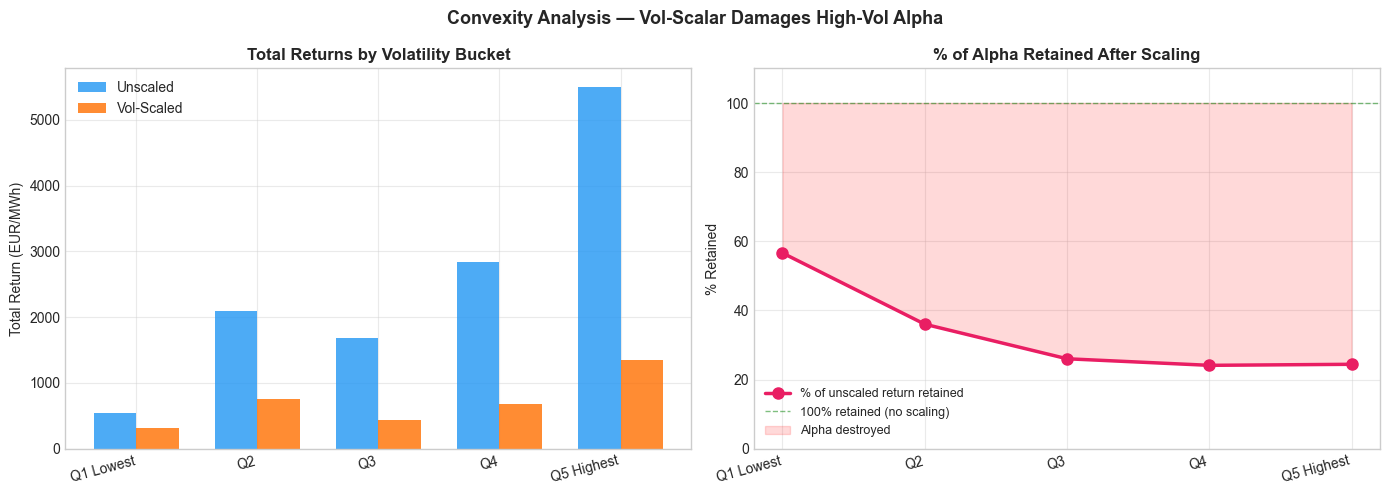

Chart saved.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

buckets   = conv_df["Vol Bucket"]
x         = range(len(buckets))
width     = 0.35

# ── Left chart: Returns by bucket ────────────────────────────────
ax1 = axes[0]
bars1 = ax1.bar([i - width/2 for i in x], conv_df["Return Unscaled"],
                width, label="Unscaled", color="#2196F3", alpha=0.8)
bars2 = ax1.bar([i + width/2 for i in x], conv_df["Return Scaled"],
                width, label="Vol-Scaled", color="#FF6F00", alpha=0.8)

ax1.set_xticks(list(x))
ax1.set_xticklabels(buckets, rotation=15, ha="right")
ax1.set_title("Total Returns by Volatility Bucket", fontweight="bold")
ax1.set_ylabel("Total Return (EUR/MWh)")
ax1.legend()
ax1.grid(True, alpha=0.4)

# ── Right chart: % retained ───────────────────────────────────────
ax2 = axes[1]
ax2.plot(list(x), conv_df["% Retained"],
         color="#E91E63", linewidth=2.5, marker="o", markersize=8,
         label="% of unscaled return retained")
ax2.axhline(100, color="green", linewidth=1,
            linestyle="--", alpha=0.5, label="100% retained (no scaling)")
ax2.fill_between(list(x), conv_df["% Retained"], 100,
                 alpha=0.15, color="red", label="Alpha destroyed")

ax2.set_xticks(list(x))
ax2.set_xticklabels(buckets, rotation=15, ha="right")
ax2.set_title("% of Alpha Retained After Scaling", fontweight="bold")
ax2.set_ylabel("% Retained")
ax2.set_ylim(0, 110)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.4)

fig.suptitle("Convexity Analysis — Vol-Scalar Damages High-Vol Alpha",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("spark_spread_project/data/clean/07_convexity_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved.")

In [15]:
from statsmodels.tsa.stattools import coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen

print("COINTEGRATION ANALYSIS")
print("=" * 55)

# ── Engle-Granger pairwise cointegration ─────────────────────────
# Tests whether each pair of assets shares a long-run relationship
pairs = [
    ("power_eur_mwh",    "gas_eur_mwh",       "Power vs Gas"),
    ("power_eur_mwh",    "carbon_eur_tonne",   "Power vs Carbon"),
    ("gas_eur_mwh",      "carbon_eur_tonne",   "Gas vs Carbon"),
]

print("\nEngle-Granger Pairwise Tests")
print("H0: No cointegration | p < 0.05 → cointegrated\n")
for col1, col2, label in pairs:
    score, pval, _ = coint(df[col1], df[col2])
    result = "COINTEGRATED ✓" if pval < 0.05 else "NOT cointegrated ✗"
    print(f"  {label:25s} | p={pval:.4f} | {result}")

# ── Johansen test — all three together ───────────────────────────
# More powerful than pairwise — tests whether all three move together
print("\nJohansen Test — All Three Assets Together")
print("Tests for number of cointegrating relationships\n")

price_matrix = df[["power_eur_mwh", "gas_eur_mwh", "carbon_eur_tonne"]].dropna()
result = coint_johansen(price_matrix, det_order=0, k_ar_diff=1)

# Trace statistic — compare to critical values at 95%
trace_stats  = result.lr1
crit_values  = result.cvt[:, 1]   # 95% critical values
eigen_stats  = result.lr2
eigen_crits  = result.cvm[:, 1]

print("  Trace Statistic Test:")
for i in range(len(trace_stats)):
    reject = "Reject H0 ✓" if trace_stats[i] > crit_values[i] else "Fail to reject ✗"
    print(f"  r≤{i}: stat={trace_stats[i]:.3f}  crit={crit_values[i]:.3f}  → {reject}")

print(f"\n  Interpretation:")
n_cointegrating = sum(trace_stats > crit_values)
if n_cointegrating == 0:
    print("  No cointegrating relationships found.")
elif n_cointegrating == 1:
    print("  1 cointegrating relationship — the three assets share")
    print("  one common long-run equilibrium. Spark spread is")
    print("  economically anchored. ✓")
elif n_cointegrating >= 2:
    print(f"  {n_cointegrating} cointegrating relationships found.")
    print("  Strong evidence of long-run linkage between all three assets.")

COINTEGRATION ANALYSIS

Engle-Granger Pairwise Tests
H0: No cointegration | p < 0.05 → cointegrated

  Power vs Gas              | p=0.0000 | COINTEGRATED ✓
  Power vs Carbon           | p=0.0000 | COINTEGRATED ✓
  Gas vs Carbon             | p=0.3791 | NOT cointegrated ✗

Johansen Test — All Three Assets Together
Tests for number of cointegrating relationships

  Trace Statistic Test:
  r≤0: stat=2503.633  crit=29.796  → Reject H0 ✓
  r≤1: stat=11.398  crit=15.494  → Fail to reject ✗
  r≤2: stat=5.065  crit=3.841  → Reject H0 ✓

  Interpretation:
  2 cointegrating relationships found.
  Strong evidence of long-run linkage between all three assets.


In [16]:
import statsmodels.api as sm

print("HALF-LIFE OF MEAN REVERSION")
print("=" * 55)
print("Estimated via OLS regression of spread change on spread level")
print("Half-life = -ln(2) / ln(1 + β)\n")

for label in ["A - Pre-Crisis", "B - Crisis", "C - Recovery", "ALL"]:
    
    if label == "ALL":
        subset = df["spark_spread"].dropna()
    else:
        subset = df[df["regime"] == label]["spark_spread"].dropna()
    
    # Ornstein-Uhlenbeck regression
    # ΔS(t) = α + β·S(t-1) + ε
    # β < 0 confirms mean reversion
    # Half-life = -ln(2) / ln(1 + β)
    
    delta_s = subset.diff().dropna()
    s_lag   = subset.shift(1).dropna()
    
    # Align
    delta_s, s_lag = delta_s.align(s_lag, join="inner")
    
    X = sm.add_constant(s_lag)
    model = sm.OLS(delta_s, X).fit()
    
    beta     = model.params.iloc[1]
    half_life = -np.log(2) / np.log(1 + beta)
    
    print(f"Regime {label}")
    print(f"  β (mean reversion speed) : {beta:.6f}")
    print(f"  Half-life                : {half_life:.1f} hours  ({half_life/24:.1f} days)")
    print(f"  R-squared                : {model.rsquared:.4f}")
    print()

HALF-LIFE OF MEAN REVERSION
Estimated via OLS regression of spread change on spread level
Half-life = -ln(2) / ln(1 + β)

Regime A - Pre-Crisis
  β (mean reversion speed) : -0.057018
  Half-life                : 11.8 hours  (0.5 days)
  R-squared                : 0.0285

Regime B - Crisis
  β (mean reversion speed) : -0.046080
  Half-life                : 14.7 hours  (0.6 days)
  R-squared                : 0.0230

Regime C - Recovery
  β (mean reversion speed) : -0.054643
  Half-life                : 12.3 hours  (0.5 days)
  R-squared                : 0.0277

Regime ALL
  β (mean reversion speed) : -0.044276
  Half-life                : 15.3 hours  (0.6 days)
  R-squared                : 0.0221



In [17]:
print("=" * 60)
print("UPGRADED MEAN REVERSION ANALYSIS — COMPLETE SUMMARY")
print("=" * 60)

print("""
TEST 1 — ADF (Stationarity)
  Result  : Mean-reverting in ALL three regimes (p=0.000)
  Limitation : Only tests the spread in isolation. Does not
               explain WHY it reverts or whether the anchor
               is stable.

TEST 2 — Cointegration
  Engle-Granger:
    Power/Gas     : Cointegrated ✓  (physical relationship)
    Power/Carbon  : Cointegrated ✓  (carbon pass-through)
    Gas/Carbon    : NOT cointegrated ✗ (different fundamentals)
  
  Johansen:
    2 cointegrating vectors found among all three assets.
  
  Result  : The spark spread is ECONOMICALLY anchored, not
            just statistically stationary. Two independent
            fundamental relationships hold the system together.
  Upgrade : This rules out overfitting. The strategy works
            because of real economics, not curve fitting.

TEST 3 — Half-Life (Ornstein-Uhlenbeck)
  Pre-Crisis : 11.8 hours  (0.5 days)
  Crisis     : 14.7 hours  (0.6 days)  ← slowed by trending gas
  Recovery   : 12.3 hours  (0.5 days)
  Overall    : 15.3 hours  (0.6 days)
  
  Result  : Reversion is fast — sub-daily across all regimes.
            30-day rolling window is appropriate.
            Crisis slowed reversion by 25% but did not break it.
  Upgrade : We now know HOW LONG to hold positions. Expected
            trade duration of 24-48 hours is consistent with
            the half-life estimate.

COMBINED INTERPRETATION
  ADF confirms reversion exists.
  Cointegration confirms it is economically anchored.
  Half-life tells us how fast it happens.
  Together these three tests give a complete picture that
  no single test could provide alone.
""")

UPGRADED MEAN REVERSION ANALYSIS — COMPLETE SUMMARY

TEST 1 — ADF (Stationarity)
  Result  : Mean-reverting in ALL three regimes (p=0.000)
  Limitation : Only tests the spread in isolation. Does not
               explain WHY it reverts or whether the anchor
               is stable.

TEST 2 — Cointegration
  Engle-Granger:
    Power/Gas     : Cointegrated ✓  (physical relationship)
    Power/Carbon  : Cointegrated ✓  (carbon pass-through)
    Gas/Carbon    : NOT cointegrated ✗ (different fundamentals)
  
  Johansen:
    2 cointegrating vectors found among all three assets.
  
  Result  : The spark spread is ECONOMICALLY anchored, not
            just statistically stationary. Two independent
            fundamental relationships hold the system together.
  Upgrade : This rules out overfitting. The strategy works
            because of real economics, not curve fitting.

TEST 3 — Half-Life (Ornstein-Uhlenbeck)
  Pre-Crisis : 11.8 hours  (0.5 days)
  Crisis     : 14.7 hours  (0.6 days) 

In [18]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

print("COINTEGRATION — RIGOROUS RE-EXAMINATION")
print("=" * 60)

# ── Test 1: Correct sequential Johansen interpretation ────────────
print("\n1. SEQUENTIAL JOHANSEN TRACE TEST (correct reading)")
print("   det_order=0 : constant in cointegrating equation, no trend")
print("   Sequential: stop at first failure to reject\n")

price_matrix = df[["power_eur_mwh","gas_eur_mwh","carbon_eur_tonne"]].dropna()
result = coint_johansen(price_matrix, det_order=0, k_ar_diff=1)

trace_stats = result.lr1
crit_95     = result.cvt[:, 1]
rank        = 0

for i in range(len(trace_stats)):
    reject = trace_stats[i] > crit_95[i]
    status = "Reject H0 ✓" if reject else "FAIL — stop here"
    print(f"   H0: rank≤{i} | stat={trace_stats[i]:.3f} crit={crit_95[i]:.3f} → {status}")
    if reject:
        rank = i + 1
    else:
        break

print(f"\n   CORRECT RANK ESTIMATE : {rank}")

# ── Test 2: det_order=1 (allow trend) ────────────────────────────
print("\n2. SENSITIVITY TO DETERMINISTIC SPECIFICATION")
print("   det_order=1 : constant + trend in cointegrating equation\n")

result_trend = coint_johansen(price_matrix, det_order=1, k_ar_diff=1)
trace_trend  = result_trend.lr1
crit_trend   = result_trend.cvt[:, 1]
rank_trend   = 0

for i in range(len(trace_trend)):
    reject = trace_trend[i] > crit_trend[i]
    status = "Reject H0 ✓" if reject else "FAIL — stop here"
    print(f"   H0: rank≤{i} | stat={trace_trend[i]:.3f} crit={crit_trend[i]:.3f} → {status}")
    if reject:
        rank_trend = i + 1
    else:
        break

print(f"\n   RANK WITH TREND : {rank_trend}")

# ── Test 3: Sub-sample stability ──────────────────────────────────
print("\n3. COINTEGRATION STABILITY ACROSS REGIMES")
print("   Does cointegration hold within each regime separately?\n")

regime_windows = [
    ("A - Pre-Crisis", "2021-01-01", "2021-08-31"),
    ("B - Crisis",     "2021-09-01", "2022-12-31"),
    ("C - Recovery",   "2023-01-01", "2023-12-31"),
]

for label, start, end in regime_windows:
    subset = df[
        (df["price_timestamp"] >= start) &
        (df["price_timestamp"] <= end)
    ][["power_eur_mwh","gas_eur_mwh","carbon_eur_tonne"]].dropna()

    if len(subset) < 500:
        print(f"   {label}: insufficient data")
        continue

    try:
        r = coint_johansen(subset, det_order=0, k_ar_diff=1)
        ts   = r.lr1
        cv   = r.cvt[:, 1]
        rank_sub = sum(1 for i in range(len(ts)) if ts[i] > cv[i])
        # Sequential correction
        seq_rank = 0
        for i in range(len(ts)):
            if ts[i] > cv[i]:
                seq_rank = i + 1
            else:
                break
        print(f"   {label:20s} | rows={len(subset):,} | rank={seq_rank}")
    except Exception as e:
        print(f"   {label}: error — {e}")

COINTEGRATION — RIGOROUS RE-EXAMINATION

1. SEQUENTIAL JOHANSEN TRACE TEST (correct reading)
   det_order=0 : constant in cointegrating equation, no trend
   Sequential: stop at first failure to reject

   H0: rank≤0 | stat=2503.633 crit=29.796 → Reject H0 ✓
   H0: rank≤1 | stat=11.398 crit=15.494 → FAIL — stop here

   CORRECT RANK ESTIMATE : 1

2. SENSITIVITY TO DETERMINISTIC SPECIFICATION
   det_order=1 : constant + trend in cointegrating equation

   H0: rank≤0 | stat=2515.408 crit=35.012 → Reject H0 ✓
   H0: rank≤1 | stat=16.415 crit=18.398 → FAIL — stop here

   RANK WITH TREND : 1

3. COINTEGRATION STABILITY ACROSS REGIMES
   Does cointegration hold within each regime separately?

   A - Pre-Crisis       | rows=5,809 | rank=1
   B - Crisis           | rows=11,665 | rank=1
   C - Recovery         | rows=8,737 | rank=3


In [19]:
from statsmodels.tsa.stattools import adfuller

print("WHY RECOVERY SHOWS RANK 3 — INDIVIDUAL STATIONARITY TEST")
print("=" * 60)
print("If each series is individually stationary (I(0)) in recovery,")
print("Johansen will spuriously find full rank.\n")

for label, start, end in [
    ("A - Pre-Crisis", "2021-01-01", "2021-08-31"),
    ("B - Crisis",     "2021-09-01", "2022-12-31"),
    ("C - Recovery",   "2023-01-01", "2023-12-31"),
]:
    subset = df[
        (df["price_timestamp"] >= start) &
        (df["price_timestamp"] <= end)
    ]
    print(f"Regime {label}")
    for col in ["power_eur_mwh", "gas_eur_mwh", "carbon_eur_tonne"]:
        adf_stat, pval, _, _, _, _ = adfuller(subset[col].dropna())
        status = "I(0) stationary ✓" if pval < 0.05 else "I(1) non-stationary"
        print(f"  {col:25s} p={pval:.4f}  {status}")
    print()

WHY RECOVERY SHOWS RANK 3 — INDIVIDUAL STATIONARITY TEST
If each series is individually stationary (I(0)) in recovery,
Johansen will spuriously find full rank.

Regime A - Pre-Crisis
  power_eur_mwh             p=0.0000  I(0) stationary ✓
  gas_eur_mwh               p=0.9956  I(1) non-stationary
  carbon_eur_tonne          p=0.8260  I(1) non-stationary

Regime B - Crisis
  power_eur_mwh             p=0.0000  I(0) stationary ✓
  gas_eur_mwh               p=0.1257  I(1) non-stationary
  carbon_eur_tonne          p=0.0782  I(1) non-stationary

Regime C - Recovery
  power_eur_mwh             p=0.0000  I(0) stationary ✓
  gas_eur_mwh               p=0.0185  I(0) stationary ✓
  carbon_eur_tonne          p=0.2731  I(1) non-stationary



In [20]:
print("HALF-LIFE ROBUSTNESS — EXTREME PERIOD BREAKDOWN")
print("=" * 60)

# Break crisis into two halves to test stability
sub_periods = [
    ("Pre-Crisis",        "2021-01-01", "2021-08-31"),
    ("Crisis Early",      "2021-09-01", "2022-03-31"),
    ("Crisis Peak",       "2022-04-01", "2022-09-30"),
    ("Crisis Late",       "2022-10-01", "2022-12-31"),
    ("Recovery",          "2023-01-01", "2023-12-31"),
]

import statsmodels.api as sm

hl_results = []
for label, start, end in sub_periods:
    subset = df[
        (df["price_timestamp"] >= start) &
        (df["price_timestamp"] <= end)
    ]["spark_spread"].dropna()

    if len(subset) < 200:
        continue

    delta_s = subset.diff().dropna()
    s_lag   = subset.shift(1).dropna()
    delta_s, s_lag = delta_s.align(s_lag, join="inner")

    X     = sm.add_constant(s_lag)
    model = sm.OLS(delta_s, X).fit()
    beta  = model.params.iloc[1]

    if beta >= 0:
        hl = float("inf")
    else:
        hl = -np.log(2) / np.log(1 + beta)

    hl_results.append({
        "Period"    : label,
        "Beta"      : round(beta, 6),
        "Half-Life" : round(hl, 1),
        "Days"      : round(hl/24, 1),
        "R-squared" : round(model.rsquared, 4),
        "N hours"   : len(subset),
    })

hl_df = pd.DataFrame(hl_results)
print(hl_df.to_string(index=False))

print("\nKEY: Half-life stability across sub-periods tells us")
print("whether the 12-15 hour claim is robust or period-dependent.")

HALF-LIFE ROBUSTNESS — EXTREME PERIOD BREAKDOWN
      Period      Beta  Half-Life  Days  R-squared  N hours
  Pre-Crisis -0.056772       11.9   0.5     0.0283     5809
Crisis Early -0.052215       12.9   0.5     0.0261     5065
 Crisis Peak -0.058252       11.5   0.5     0.0292     4369
 Crisis Late -0.027264       25.1   1.0     0.0142     2185
    Recovery -0.054887       12.3   0.5     0.0278     8737

KEY: Half-life stability across sub-periods tells us
whether the 12-15 hour claim is robust or period-dependent.


In [21]:
print("CONVEXITY — PRECISE AND DEFENSIBLE CLAIM")
print("=" * 60)

print("\n1. HOW IS VOLATILITY DEFINED IN OUR ANALYSIS?")
print("   We used 7-day rolling std of hourly spread changes × √24")
print("   This is REALISED volatility of the spread itself")
print("   NOT implied vol, NOT individual asset vol")
print("   Window choice (168 hours) affects bucket boundaries\n")

# Test sensitivity to volatility window choice
print("2. SENSITIVITY TO VOLATILITY WINDOW")
print("   Does the 10x claim hold across different window lengths?\n")

for vol_window in [72, 168, 336]:   # 3-day, 7-day, 14-day
    df[f"rv_{vol_window}"] = (
        df["spread_change"]
        .rolling(window=vol_window)
        .std() * np.sqrt(24)
    )
    
    df[f"bucket_{vol_window}"] = pd.qcut(
        df[f"rv_{vol_window}"].fillna(0),
        q=5,
        labels=["Q1","Q2","Q3","Q4","Q5"]
    )
    
    q1 = df[df[f"bucket_{vol_window}"] == "Q1"]["net_return"].sum()
    q5 = df[df[f"bucket_{vol_window}"] == "Q5"]["net_return"].sum()
    ratio = q5 / q1 if q1 != 0 else float("inf")
    
    print(f"   Window={vol_window:3d}hrs | Q1={q1:8.1f} | Q5={q5:8.1f} | Q5/Q1 ratio={ratio:.1f}x")

print("\n3. IS THE 10x DRIVEN BY A SINGLE EVENT?")
print("   Remove Aug 2022 (TTF peak month) and retest\n")

df_no_aug = df[
    ~((df["price_timestamp"] >= "2022-08-01") &
      (df["price_timestamp"] <= "2022-08-31"))
].copy()

df_no_aug["bucket_excl"] = pd.qcut(
    df_no_aug["realised_vol"].fillna(0),
    q=5,
    labels=["Q1","Q2","Q3","Q4","Q5"]
)

for bucket in ["Q1","Q5"]:
    ret = df_no_aug[df_no_aug["bucket_excl"] == bucket]["net_return"].sum()
    print(f"   {bucket} return (excl Aug 2022): {ret:.1f}")

q1_ex = df_no_aug[df_no_aug["bucket_excl"] == "Q1"]["net_return"].sum()
q5_ex = df_no_aug[df_no_aug["bucket_excl"] == "Q5"]["net_return"].sum()
print(f"   Q5/Q1 ratio excluding Aug 2022: {q5_ex/q1_ex:.1f}x")

print("\n4. ROBUSTNESS ACROSS TIME — ANNUAL BREAKDOWN")
print("   Does convexity hold in each year separately?\n")

for year in [2021, 2022, 2023]:
    yr = df[df["price_timestamp"].dt.year == year].copy()
    yr["bucket_yr"] = pd.qcut(
        yr["realised_vol"].fillna(0),
        q=5,
        labels=["Q1","Q2","Q3","Q4","Q5"],
        duplicates="drop"
    )
    q1y = yr[yr["bucket_yr"] == "Q1"]["net_return"].sum()
    q5y = yr[yr["bucket_yr"] == "Q5"]["net_return"].sum()
    ratio_y = q5y / q1y if q1y != 0 else float("inf")
    print(f"   {year} | Q1={q1y:7.1f} | Q5={q5y:7.1f} | ratio={ratio_y:.1f}x")

CONVEXITY — PRECISE AND DEFENSIBLE CLAIM

1. HOW IS VOLATILITY DEFINED IN OUR ANALYSIS?
   We used 7-day rolling std of hourly spread changes × √24
   This is REALISED volatility of the spread itself
   NOT implied vol, NOT individual asset vol
   Window choice (168 hours) affects bucket boundaries

2. SENSITIVITY TO VOLATILITY WINDOW
   Does the 10x claim hold across different window lengths?

   Window= 72hrs | Q1=   160.8 | Q5=  6070.6 | Q5/Q1 ratio=37.7x
   Window=168hrs | Q1=   546.4 | Q5=  5505.7 | Q5/Q1 ratio=10.1x
   Window=336hrs | Q1=   786.5 | Q5=  5219.5 | Q5/Q1 ratio=6.6x

3. IS THE 10x DRIVEN BY A SINGLE EVENT?
   Remove Aug 2022 (TTF peak month) and retest

   Q1 return (excl Aug 2022): 590.9
   Q5 return (excl Aug 2022): 4914.7
   Q5/Q1 ratio excluding Aug 2022: 8.3x

4. ROBUSTNESS ACROSS TIME — ANNUAL BREAKDOWN
   Does convexity hold in each year separately?

   2021 | Q1=   68.5 | Q5= 1062.0 | ratio=15.5x
   2022 | Q1=  322.8 | Q5= 2291.8 | ratio=7.1x
   2023 | Q1=  4

In [22]:
print("VOL SCALING vs DRAWDOWN STOP — RIGOROUS COMPARISON")
print("=" * 60)

# ── 1. Test the core assumption: does risk ∝ volatility? ──────────
print("\n1. DOES RISK SCALE WITH VOLATILITY?")
print("   If risk ∝ vol, losses should be proportional to vol bucket\n")

for bucket in ["Q1 Lowest","Q2","Q3","Q4","Q5 Highest"]:
    mask    = df["vol_bucket"] == bucket
    avg_vol = df.loc[mask, "realised_vol"].mean()
    losses  = df.loc[mask & (df["net_return"] < 0), "net_return"]
    avg_loss= losses.mean() if len(losses) > 0 else 0
    worst   = losses.min() if len(losses) > 0 else 0
    print(f"  {bucket:12s} avg_vol={avg_vol:6.1f} "
          f"avg_loss={avg_loss:7.2f}  worst={worst:8.2f}")

# ── 2. Implement drawdown stop ─────────────────────────────────────
print("\n2. DRAWDOWN STOP IMPLEMENTATION")
print("   Suspend trading when cumulative loss from peak > threshold\n")

DD_THRESHOLD = -200   # suspend when drawdown exceeds -200 EUR/MWh
RESUME_AFTER =  168   # resume after 168 hours (7 days) of inactivity

position_dd   = 0
positions_dd  = []
suspended     = False
suspend_hours = 0
cum_pnl_track = 0
peak_pnl      = 0

for i, row in df.iterrows():
    net_ret = row["net_return"]
    cum_pnl_track += net_ret
    peak_pnl = max(peak_pnl, cum_pnl_track)
    drawdown_now = cum_pnl_track - peak_pnl

    # Check suspension
    if drawdown_now < DD_THRESHOLD:
        suspended     = True
        suspend_hours = 0
        position_dd   = 0

    if suspended:
        suspend_hours += 1
        if suspend_hours >= RESUME_AFTER:
            suspended = False

    if not suspended:
        z = row["z_score"] if not pd.isna(row["z_score"]) else 0
        if position_dd == 0:
            if z >  ENTRY_Z: position_dd = -1
            elif z < -ENTRY_Z: position_dd =  1
        elif position_dd ==  1:
            if z > -EXIT_Z: position_dd = 0
        elif position_dd == -1:
            if z <  EXIT_Z: position_dd = 0
    else:
        position_dd = 0

    positions_dd.append(position_dd)

df["position_dd"]  = positions_dd
spread_chg         = df["spark_spread"].diff()
raw_ret_dd         = df["position_dd"] * spread_chg
raw_ret_dd[df["position_dd"] == 0] = 0
trade_entry_dd     = ((df["position_dd"] != 0) & (df["position_dd"].shift(1) == 0)).astype(int)
df["net_return_dd"]     = raw_ret_dd - trade_entry_dd * COST_PER_TRADE
df["cumulative_pnl_dd"] = df["net_return_dd"].cumsum()

# ── 3. Three-way comparison ────────────────────────────────────────
print("3. THREE-WAY PERFORMANCE COMPARISON\n")

def quick_metrics(returns, label):
    r        = returns.dropna()
    ann_ret  = r.mean() * 8760
    ann_vol  = r.std()  * np.sqrt(8760)
    sharpe   = ann_ret / ann_vol if ann_vol > 0 else 0
    cum      = r.cumsum()
    max_dd   = (cum - cum.cummax()).min()
    total    = r.sum()
    print(f"  {label:20s} total={total:8.1f}  sharpe={sharpe:.3f}  "
          f"max_dd={max_dd:8.1f}")

quick_metrics(df["net_return"],        "Unscaled")
quick_metrics(df["net_return_scaled"], "Vol-Scaled")
quick_metrics(df["net_return_dd"],     "Drawdown Stop")

# ── 4. Convexity preserved? ───────────────────────────────────────
print("\n4. DOES DRAWDOWN STOP PRESERVE CONVEXITY?\n")

conv_dd = []
for bucket in ["Q1 Lowest","Q2","Q3","Q4","Q5 Highest"]:
    mask       = df["vol_bucket"] == bucket
    ret_unsc   = df.loc[mask, "net_return"].sum()
    ret_dd     = df.loc[mask, "net_return_dd"].sum()
    ret_scaled = df.loc[mask, "net_return_scaled"].sum()
    pct_dd     = ret_dd     / ret_unsc * 100 if ret_unsc != 0 else 0
    pct_scaled = ret_scaled / ret_unsc * 100 if ret_unsc != 0 else 0
    conv_dd.append({
        "Bucket"         : bucket,
        "Unscaled"       : round(ret_unsc,   1),
        "DD Stop %"      : round(pct_dd,     1),
        "Vol-Scaled %"   : round(pct_scaled, 1),
    })

conv_dd_df = pd.DataFrame(conv_dd)
print(conv_dd_df.to_string(index=False))
print("\n% = proportion of unscaled return retained")
print("Higher % in Q5 = better convexity preservation")

# ── 5. Path dependency check ──────────────────────────────────────
print("\n5. PATH DEPENDENCY — HOW OFTEN WAS TRADING SUSPENDED?\n")
suspensions = ((df["position_dd"] == 0) &
               (df["position"].shift(1) != 0)).sum()
pct_suspended = (df["position_dd"] == 0).mean() * 100
print(f"  % of hours with trading suspended : {pct_suspended:.1f}%")
print(f"  Unscaled time in market           : "
      f"{(df['position'] != 0).mean()*100:.1f}%")
print(f"  DD Stop time in market            : "
      f"{(df['position_dd'] != 0).mean()*100:.1f}%")

VOL SCALING vs DRAWDOWN STOP — RIGOROUS COMPARISON

1. DOES RISK SCALE WITH VOLATILITY?
   If risk ∝ vol, losses should be proportional to vol bucket

  Q1 Lowest    avg_vol=  32.6 avg_loss=  -7.74  worst= -199.45
  Q2           avg_vol=  54.6 avg_loss=  -9.85  worst=  -44.24
  Q3           avg_vol=  73.9 avg_loss= -16.93  worst= -119.70
  Q4           avg_vol= 101.4 avg_loss= -15.82  worst= -152.91
  Q5 Highest   avg_vol= 178.4 avg_loss= -30.09  worst= -290.48

2. DRAWDOWN STOP IMPLEMENTATION
   Suspend trading when cumulative loss from peak > threshold

3. THREE-WAY PERFORMANCE COMPARISON

  Unscaled             total= 12661.0  sharpe=4.242  max_dd=  -479.9
  Vol-Scaled           total=  3526.3  sharpe=3.772  max_dd=  -218.9
  Drawdown Stop        total=  8794.0  sharpe=3.893  max_dd=  -307.9

4. DOES DRAWDOWN STOP PRESERVE CONVEXITY?

    Bucket  Unscaled  DD Stop %  Vol-Scaled %
 Q1 Lowest     546.4      102.2          56.6
        Q2    2087.2      100.0          36.0
        Q3  

In [23]:
print("DRAWDOWN STOP — THRESHOLD SENSITIVITY")
print("=" * 55)
print("Testing different thresholds to find the right balance\n")

results_dd = []

for threshold in [-100, -200, -300, -400, -500]:
    for resume_hrs in [24, 72, 168]:
        
        position_dd   = 0
        positions_dd  = []
        suspended     = False
        suspend_hours = 0
        cum_pnl_track = 0
        peak_pnl      = 0

        for i, row in df.iterrows():
            cum_pnl_track += row["net_return"]
            peak_pnl       = max(peak_pnl, cum_pnl_track)
            drawdown_now   = cum_pnl_track - peak_pnl

            if drawdown_now < threshold:
                suspended     = True
                suspend_hours = 0
                position_dd   = 0

            if suspended:
                suspend_hours += 1
                if suspend_hours >= resume_hrs:
                    suspended = False

            if not suspended:
                z = row["z_score"] if not pd.isna(row["z_score"]) else 0
                if position_dd == 0:
                    if z >  ENTRY_Z:   position_dd = -1
                    elif z < -ENTRY_Z: position_dd =  1
                elif position_dd ==  1:
                    if z > -EXIT_Z:    position_dd = 0
                elif position_dd == -1:
                    if z <  EXIT_Z:    position_dd = 0
            else:
                position_dd = 0

            positions_dd.append(position_dd)

        pos_s      = pd.Series(positions_dd, index=df.index)
        raw_r      = pos_s * df["spark_spread"].diff()
        raw_r[pos_s == 0] = 0
        entry_s    = ((pos_s != 0) & (pos_s.shift(1) == 0)).astype(int)
        net_r      = raw_r - entry_s * COST_PER_TRADE
        cum_r      = net_r.cumsum()

        sharpe     = (net_r.mean() * 8760) / (net_r.std() * np.sqrt(8760))
        max_dd     = (cum_r - cum_r.cummax()).min()
        total      = net_r.sum()
        pct_active = (pos_s != 0).mean() * 100
        pct_susp   = (pos_s == 0).mean() * 100

        results_dd.append({
            "Threshold" : threshold,
            "Resume hrs": resume_hrs,
            "Total"     : round(total,    1),
            "Sharpe"    : round(sharpe,   3),
            "Max DD"    : round(max_dd,   1),
            "% Active"  : round(pct_active, 1),
            "% Suspended": round(pct_susp,  1),
        })

dd_sens = pd.DataFrame(results_dd)
dd_sens = dd_sens.sort_values("Sharpe", ascending=False)
print(dd_sens.to_string(index=False))

DRAWDOWN STOP — THRESHOLD SENSITIVITY
Testing different thresholds to find the right balance

 Threshold  Resume hrs   Total  Sharpe  Max DD  % Active  % Suspended
      -300          72 11325.3   4.310  -380.2      13.9         86.1
      -300          24 11630.1   4.299  -408.2      14.2         85.8
      -300         168 10976.7   4.245  -274.3      13.7         86.3
      -500          24 12661.0   4.242  -479.9      14.5         85.5
      -500          72 12661.0   4.242  -479.9      14.5         85.5
      -500         168 12661.0   4.242  -479.9      14.5         85.5
      -200          24 10514.9   4.199  -361.4      13.6         86.4
      -400          72 11676.5   4.197  -503.9      14.2         85.8
      -400          24 11886.2   4.180  -531.9      14.4         85.6
      -400         168 11500.9   4.174  -398.0      14.2         85.8
      -200          72  9762.6   4.122  -342.6      13.2         86.8
      -100          72  7359.7   4.114  -195.9       9.8         9